In [74]:
import cv2 as cv
import albumentations as A
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

In [18]:
image_sample_path = Path("../../data/01_raw/sneakers-dataset/vans_sk8-hi/0129.jpg")

In [43]:
save_path = Path("../../data/02_intermediate")

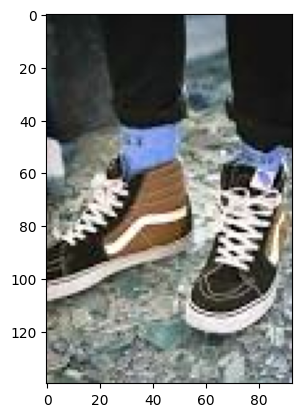

In [19]:
image_sample = cv.imread(image_sample_path)
plt.imshow(image_sample)

In [20]:
image_sample.shape

(140, 93, 3)

## Поворот, зеркальное отражение, смещение изображения

**Поворот**

In [23]:
height, width = image_sample.shape[:2]
center = (width // 2, height // 2)
angle = 30
scale = 1.0
rotation_matrix = cv.getRotationMatrix2D(center, angle, scale)

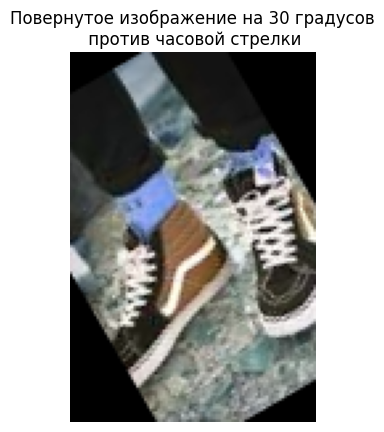

In [79]:
plt.title("Повернутое изображение на 30 градусов\n против часовой стрелки")
plt.imshow(rotated_matrix)
plt.axis("off")
plt.savefig(save_path / "vans_sk8-hi_129_rotated.jpg")
plt.show()

In [25]:
rotated_matrix = cv.warpAffine(image_sample, rotation_matrix, (width, height))

In [95]:
random_rotate = A.RandomRotate90()
rotated_image = random_rotate(image=image_sample)["image"]

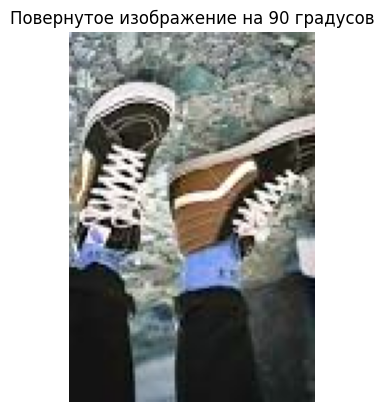

In [96]:
plt.title("Повернутое изображение на 90 градусов")
plt.imshow(rotated_image)
plt.axis("off")
# plt.savefig(save_path / 'vans_sk8-hi_129_rotated.jpg')
plt.show()

**Зеркальное отражение**

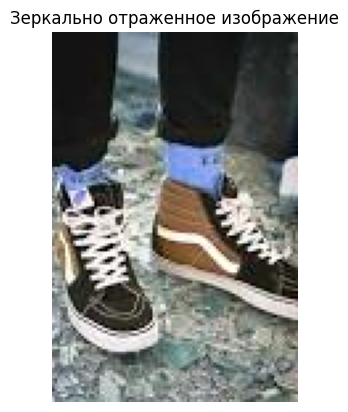

In [45]:
plt.title("Зеркально отраженное изображение")
plt.imshow(cv.flip(image_sample, 1))
plt.axis("off")
plt.savefig(save_path / "vans_sk8-hi_mirrored_image.jpg")
plt.show()

**Смещение изображения**

In [47]:
image_sample.shape

(140, 93, 3)

In [70]:
height, width = image_sample.shape[:2]

M = np.float32([[1, 0, 10], [0, 1, 7]])  # Матрица смещения изображения

translated_img = cv.warpAffine(image_sample, M, (height, width))

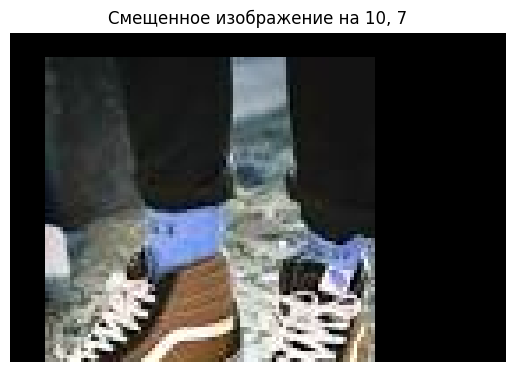

In [73]:
plt.title("Смещенное изображение на 10, 7")
plt.imshow(translated_img)
plt.axis("off")
plt.savefig(save_path / "vans_sk8-hi_translated_img.jpg")
plt.show()

## Изменение размера и кроп

**Изменение размера**

In [99]:
resize = A.Resize(height=100, width=70)

resized_img = resize(image=image_sample)["image"]

(100, 70, 3)

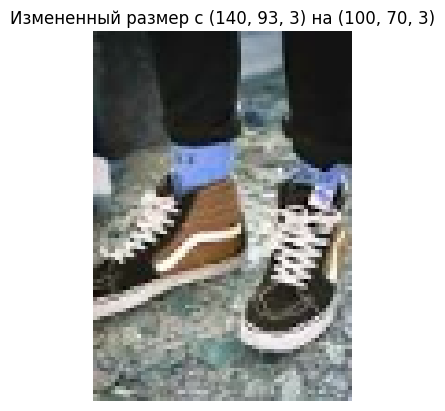

In [103]:
plt.title("Измененный размер с (140, 93, 3) на (100, 70, 3)")
plt.imshow(resized_img)
plt.axis("off")
plt.savefig(save_path / "vans_sk8-hi_resized.jpg")
resized_img.shape

**Кроп**

In [114]:
crop_tr = A.RandomCrop(height=80, width=80, pad_position="bottom_left")

cropped_image = crop_tr(image=image_sample)["image"]
cropped_image.shape

(80, 80, 3)

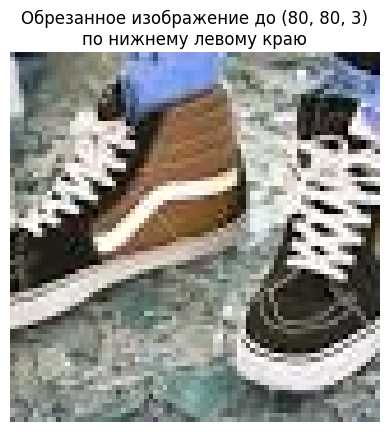

In [118]:
plt.title("Обрезанное изображение до (80, 80, 3)\nпо нижнему левому краю")
plt.imshow(cropped_image)

plt.axis("off")
plt.savefig(save_path / "vans_sk8-hi_cropped.jpg")
plt.show()

## Изменение перспективы, сжатие объектов

**Изменение перспективы**

In [137]:
affine = A.Affine(
    scale=(0.5, 2), translate_percent=(-0.05, 0.05), rotate=(-30, 30), shear=(-60, 60)
)

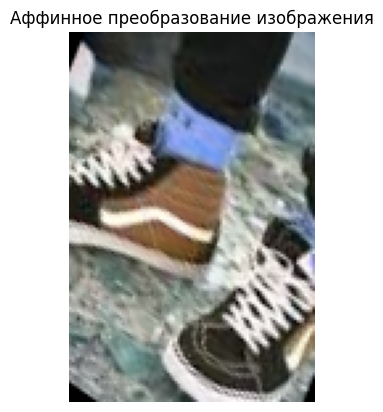

In [138]:
plt.title("Аффинное преобразование изображения")
plt.imshow(affine(image=image_sample)["image"])
plt.axis("off")
plt.savefig(save_path / "vans_sk8-hi_affine.jpg")
plt.show()

**Сжатие изображения**

## Искажение цветововой и световой гаммы изображения, добавление шума и ухудшение качества


**Изменение цвета**

In [150]:
A.ColorJitter?

Init signature:
A.ColorJitter(
    brightness: 'tuple[float, float] | float' = (0.8, 1.2),
    contrast: 'tuple[float, float] | float' = (0.8, 1.2),
    saturation: 'tuple[float, float] | float' = (0.8, 1.2),
    hue: 'tuple[float, float] | float' = (-0.5, 0.5),
    p: 'float' = 0.5,
)
Docstring:     
Randomly changes the brightness, contrast, saturation, and hue of an image.

This transform is similar to torchvision's ColorJitter but with some differences due to the use of OpenCV
instead of Pillow. The main differences are:
1. OpenCV and Pillow use different formulas to convert images to HSV format.
2. This implementation uses value saturation instead of uint8 overflow as in Pillow.

These differences may result in slightly different output compared to torchvision's ColorJitter.

Args:
    brightness (tuple[float, float] | float): How much to jitter brightness.
        If float:
            The brightness factor is chosen uniformly from [max(0, 1 - brightness), 1 + brightness].
      

In [142]:
color_jitter = A.ColorJitter(p=1.0)

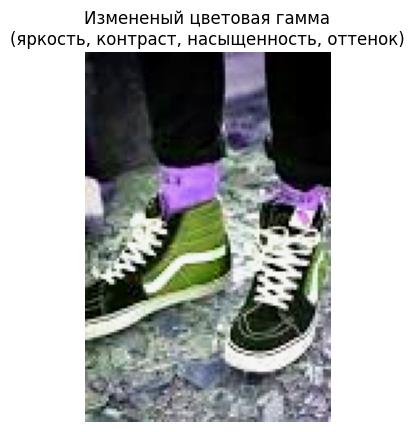

In [152]:
plt.title("Измененый цветовая гамма\n(яркость, контраст, насыщенность, оттенок)")
plt.imshow(color_jitter(image=image_sample)["image"])
plt.axis("off")
plt.savefig(save_path / "vans_sk8-hi_color_jitter.jpg")
plt.show()

**Добавление шума**

A.GaussianBlu

In [169]:
gaussian_blur = A.GaussianBlur(blur_limit=0.0, sigma_limit=(0.5, 2))

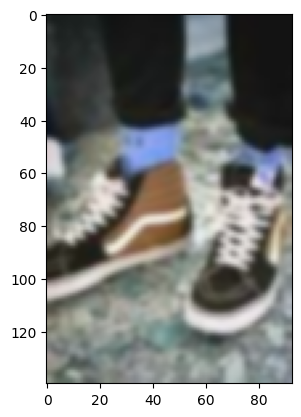

In [170]:
plt.title("Добавление блюра")
plt.imshow(gaussian_blur(image=image_sample)["image"])
plt.axis("off")

plt.savefig(save_path / "vans_sk8-hi_blur.jpg")
plt.show()

**Добавление шума**

In [189]:
gaussian_noise = A.GaussNoise(
    std_range=(0.1, 0.2),
    mean_range=(0.0, 0.0),
    per_channel=True,
    noise_scale_factor=1.0,
)

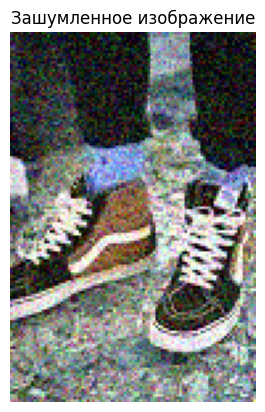

In [191]:
plt.title("Зашумленное изображение")
plt.imshow(gaussian_noise(image=image_sample)["image"])

plt.axis("off")
plt.savefig(save_path / "vans_sk8-hi_noised.jpg")
plt.show()